<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Flecha_y_cojinete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;">**Flecha y cojinete**</span>

<span style="color:teal;">**Nombre:**</span> Jerónimo López Annette Michelle

<span style="color:teal;">**Objetivo**</span> Aplicar los diferentes métodos de simulación en problemas aplicativos para estimar el número de simulaciones.

Resolver analíticamente y comparar con la solución por simulación.

Una flecha sera ensamblada en un cojinete como se muestra a continuación:

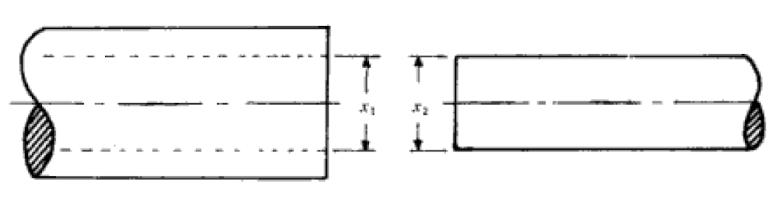


Si $x_1$ sigue una distribución normal com media $μ=1.5$ y varianza $σ^2=0.0016$ y $x_2$ esta misma distribución con media $μ=1.48$ y varianza $σ^2=0.0009$

* a) La probabilidad de que haya interferencia.
* b) El número de veces que es necesario simular el experimento, si se quiere que la probabilidad de interferencia estimada difiera de su valor verdadero en menos de $0.01$, con nivel de seguridad del $95\%$.

<span style="color:blue;">**SIMULACIÓN**</span>

* a) solución:

Usaremos el **Método de las 12 Uniformes** el cual nos dice:

Para la distribución normal

$$
f(x) = \frac{1}{\sqrt{2\pi}\,\sigma} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

Se plantea un método aproximado usando el *Teorema Central del Límite*.

Si $ x_1, x_2, \ldots, x_n $ es una muestra de $ n $ variables aleatorias independientes con $E[x_i] = \mu $ y $ \operatorname{var}(x_i) = \sigma^2 $ (ambos finitos) y
$$
Y = a_1 x_1 + a_2 x_2 + \cdots + a_n x_n,
$$
entonces
$$
Z = \frac{Y - \mu}{\sigma / \sqrt{n}}
$$
se usa la distribución normal estándar acorde a \( \alpha = 0.05 \).

Si $ X_i \sim U(0,1) $, podemos reescribir:
$$
Z = \frac{X_i - \theta}{\sqrt{\frac{\theta}{n}}}
$$

Si elegimos $ n = 12 $ y vamos al hecho de que la normal estándar de una variable aleatoria $ Y $ distribuida normalmente se obtiene así:
$$
Z = \frac{X - \mu}{\sigma / \sqrt{n}}
$$

Se llega a
$$
x= μ+σ(Σ_{i=1}^{12} R_i-6)
$$

In [ ]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

Definimos la Función Gaussiana:

In [ ]:
def gaussiana(mu,Sigma,n):
   muestra=[] #guardamos x en la lista vacía
   for i in range(n):
      Suma=0
      for j in range(12):
         u=r.random() #Creamos numeros aleatorios entre 0 y 1
         Suma=Suma+u

      x=mu + Sigma*(Suma-6)
      muestra.append(x)

   return muestra

In [ ]:
# Número de simulaciones
n = 10000

Sacamos la desviación estandar $σ$ de cada variable:

Para $X_1=σ=\sqrt{σ^2}=\sqrt{0.0016}$
* $X_1= 0.04$

Para $X_2=σ=\sqrt{σ^2}=\sqrt{0.0009}$
* $X_2= 0.03$

In [ ]:
# Generar muestras
X1 = gaussiana(1.5,0.04,n)
X2 = gaussiana(1.48,0.03,n)

In [ ]:
# Contar interferencias
interferencia = 0

for i in range(n):
   if X2[i] > X1[i]: #condición
      interferencia += 1

La Probabilidad de interferncia es:
$$
P=\frac{interferencia}{n}
$$

In [ ]:
# Probabilidad estimada
p = interferencia/n
print("Probabilidad estimada =")
p

Probabilidad estimada =


0.3411

* <span style="color:blue;">**Solución simulación** para a):

$$\boxed{0.3411}$$</span>

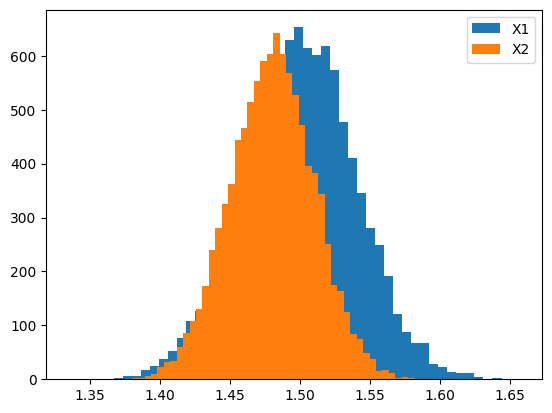

In [ ]:
plt.hist(X1,bins=50,label="X1")
plt.hist(X2,bins=50,label="X2")
plt.legend()
plt.title("Método de 12 uniformes")
plt.xlabel("Valores")
plt.show()

Intervalo de confianza de $95\%$

In [ ]:
import statsmodels.stats.proportion as smp

# Calcular el intervalo de confianza del 95% para la proporción
# Usamos el método 'wilson' que es robusto para proporciones cercanas a 0 o 1
conf_interval = smp.proportion_confint(count=interferencia, nobs=n, alpha=0.05, method='wilson')
print(f"Intervalo de confianza del 95% para la probabilidad de exceso: [{conf_interval[0]:.4f}, {conf_interval[1]:.4f}]")

Intervalo de confianza del 95% para la probabilidad de exceso: [0.3319, 0.3505]


**Número de simulaciones requerido**
Para garantizar error menor que (0.01) con 95% de confianza:


$$n=\frac{(1.96)^2p(1-p)}{(0.01)^2}$$


$$n\approx 8721$$

Por eso usar:

$n = 10000$
es suficiente.

In [ ]:
m = (1.96**2)*p*(1-p)/(0.01**2)
m

8634.02634864

<span style="color:blue;">**ANALÍTICAMENTE**</span>

* a) solución:

Tenemos un flecha con diámetro $X_1$ y un cojinete con diámetro interior $X_2$ .

Hay interferencia si $X_1 > X_2 $, es decir, si el diámetro de la flecha es mayor que el diámetro del cojinete.

Datos:

* $X_1 \sim \mathcal{N}(\mu_1 = 1.5, \sigma_1^2 = 0.0016) \quad \Rightarrow \quad \sigma_1 = 0.04$

* $X_2 \sim \mathcal{N}(\mu_2 = 1.48, \sigma_2^2 = 0.0009) \quad \Rightarrow \quad \sigma_2 = 0.03$

Se asume independencia entre $X_1$ y$ X_2 $.


**Cálculo analítico de $P(X_2 > X_1)$**

Definimos una variable $D$ como:

$$D = X_2 - X_1$$

Por independencia y normalidad:

$$\mu_D = \mu_2 - \mu_ = 1.48 - 1.5 = -0.02$$

$$\sigma_D^2 = \sigma_1^2 + \sigma_2^2 = 0.0016 + 0.0009 = 0.0025$$

$$\sigma_D = 0.05$$

Entonces tenemos que :

$$D \sim \mathcal{N}(-0.02, 0.05^2)$$

La probabilidad de interferencia es:

$$P(X_2 > X_1) = P(D > 0)$$

Estandarizamos, usando el Teorema central del Límite:

$$Z = \frac{0 -(- 0.02)}{0.05} = \frac{0.02}{0.05} = 0.4$$

$$P(D > 0) = P(Z > -0.4) = 1 - \Phi(-0.4)$$

$$\Phi(0.4) \approx 0.6554$$

Por lo  tanto:

$$P(Z > 0.4) \approx 1 - 6554 = 0.3446$$


* <span style="color:blue;">**Solución analítica** para a):

$$\boxed{0.3446}$$</span>


* <span style="color:blue;">**Número de simulaciones requerido** b)</span>

Para garantizar error menor que (0.01) con 95% de confianza de las tablas tenemos $Z= +_{-} 1.96$:

Entonces el número de simulaciones esta dado de la forma:

$$n=\frac{(1.96)^2p(1-p)}{(0.01)^2}$$

Sustituyendo el valor de probabilidad de interferencia :

$$n=\frac{(1.96)^20.3446(1-0.3446)}{(0.01)^2}$$


$$\boxed{n\approx 8676.28}$$ simulaciones

